# Plasma-frequency extraction for four JJ test structures

This notebook analyzes SEM size statistics and room-temperature resistance measurements for four test structures:

1. **Uniform wide chain**
2. **Uniform thin chain**
3. **Asymmetric SQUID** with two different junctions
4. **Single-connected SQUID** where one SQUID junction is intentionally disconnected

It is designed for complete datasets with **24 devices per structure** (tables of **6×4**) measured for **2–3 different series resistors** `R_seq`. It handles `OL` / out-of-limit entries, prioritizes lower-`R_seq` measurements to avoid dead structures biasing the statistics, and propagates both SEM area variance and measured-resistance variance into the final plasma-frequency windows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Tuple, Iterable
import scipy.constants as const

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)

# ============================================================
# Constants
# ============================================================
e = const.e
h = const.h
pi = np.pi
R_Q = h / (4 * e**2)      # superconducting resistance quantum for Cooper pairs [Ohm]

# Existing wp_calc notebook used Delta_Al ≈ 0.163 meV.
Delta_Al_J = 0.163e-3 * e

# Junction capacitance density. Replace if you have a fab-specific calibration.
C_J_density_F_per_um2 = 45e-15

print(f"R_Q = {R_Q:.2f} Ohm")
print(f"Delta_Al/h = {Delta_Al_J/h/1e9:.2f} GHz")

R_Q = 6453.20 Ohm
Delta_Al/h = 39.41 GHz


## 1. Inputs and selection knobs

Replace the dummy data below with your measured SEM sizes and resistance tables.

### Important knob
`R_SELECTION["mad_z_thresh"]` is the main knob deciding which finite resistance observations are considered consistent with the trusted low-`R_seq` population. Lower values are stricter; higher values include broader distributions.

### Resistance table format
For each structure, you can provide either a flat list of observations or `resistance_tables_by_Rseq`. The table format is preferred for your complete data:

```python
"resistance_tables_by_Rseq": {
    10.0: [[... 6 columns ...], ... 4 rows ...],
    100.0: [[...], ...],
}
````

Values can be numbers, strings like `"OL"`, `"open"`, `None`, or `np.inf`. Units are controlled by `resistance_unit`.

In [2]:
# ============================================================
# Resistance-selection knobs
# ============================================================
R_SELECTION = {
    # Main knob: robust MAD z-score threshold for accepting measurements.
    # Increase => keep more spread / possible dead structures.
    # Decrease => stricter filtering.
    "mad_z_thresh": 3.5,

    # Minimum allowed net resistance after subtracting R_seq.
    # Use this to reject accidental shorts / obvious bad contacts.
    "min_net_R_ohm": 1.0,

    # Strategy:
    #   "lowest_rseq_trusted_sites" = use the lowest-R_seq table to identify good device IDs;
    #                                final R distribution uses lowest available R_seq for those IDs.
    # This prevents high-R_seq tables with many finite-but-dead structures from dominating.
    "strategy": "lowest_rseq_trusted_sites",

    # Quantiles used for the final R window.
    "window_quantiles": (0.16, 0.84),
}

# ============================================================
# Real resistance data transcribed from lab notebook photos.
# Values are R_meas BEFORE subtracting R_seq.
# Units here are kOhm.
#
# Notes:
# - "OL" / np.inf means out-of-limit / open / invalid.
# - Some values are hard to read in the photo; they are kept as best-effort
#   transcription and should be checked against the paper notebook.
# - Chain junction_count is still a user knob: edit if the chain test structures
#   do not contain 20 junctions.
# ============================================================

# Wide chain m4_4
wide_Rseq_100k = [
    [205.9, 189.2, 196.1, 192.8],
    [198.3, 117.0, 193.7, 196.5],
    [115.0, 116.1, 193.9, 176.3],
    [113.1, 194.4, 110.6, 115.3],
    [195.2, 204.0, 116.8, 108.8],
    [190.3, 209.3, 195.2, 193.0],
]

wide_Rseq_10k = [
    ["OL", "OL", "OL", "OL"],
    ["OL", 22.88, "OL", "OL"],
    [24.86, 26.27, "OL", "OL"],
    [23.13, "OL", 20.32, 25.29],
    ["OL", "OL", 26.79, 18.84],
    ["OL", "OL", "OL", "OL"],
]

# Single-JJ SQUID m4_1, one connected junction. The 2nd JJ is intentionally disconnected / unavailable.
single_squid_Rseq_10k = [
    [11.27, 11.03, 11.04, 10.78],
    [10.91, 10.88, 10.80, 10.78],
    [10.95, 10.75, 10.79, 10.79],
    [11.18, 10.96, 10.80, 10.88],
    [11.28, 11.03, 11.28, 10.98],
    [10.79, 10.89, 10.83, 10.80],
]

single_squid_Rseq_1k = [
    [2.280, 2.039, 2.051, 1.793],
    [1.925, 1.899, 1.810, 1.794],
    [1.963, 1.765, 1.805, 1.802],
    [2.202, 1.928, 1.819, 1.894],
    [2.288, 2.043, 2.285, 1.991],
    [1.808, 1.893, 1.817, 1.816],
]

# Full SQUID m4_2, two different connected junctions in parallel.
squid_Rseq_10k = [
    [10.69, 10.66, "OL", 10.62],
    [11.05, 10.66, 10.70, 10.66],
    [10.86, 10.70, 10.64, 10.61],
    [11.29, 10.80, 10.66, 10.65],
    [10.78, 10.65, 10.63, 10.63],
    [10.84, 10.65, 10.58, 10.88],
]

squid_Rseq_1k = [
    [1.707, 1.667, "OL", 1.639],
    [2.064, 1.679, 1.741, 1.673],
    [1.875, 1.720, 1.656, 1.622],
    [2.259, 1.825, 1.676, 1.660],
    [1.798, 1.668, 1.646, 1.644],
    [1.860, 1.668, 1.605, 1.894],
]

# Thin chain m4_3. Use only the complete R_seq = 10.00 kOhm table.
thin_Rseq_10k = [
    [27.23, 29.08, 56.88, 55.18],
    [44.56, 58.30, 52.29, 53.82],
    [31.99, 48.95, 28.99, 62.72],
    [31.41, 42.17, 35.35, 56.77],
    [55.51, 27.36, "OL", 30.84],
    [53.76, "OL", 32.60, "OL"],
]

# ============================================================
# SEM dimensions.
# User provided widths in nm and lengths in um, so widths are converted to um.
# ============================================================
def nm_by_um_to_um(width_nm, length_um):
    return (width_nm * 1e-3, length_um)

TEST_STRUCTURES = {
    "m4_4_wide_chain": {
        "kind": "uniform_chain",
        "description": "Uniform wide chain m4_4.",
        "junction_count": 20,  # EDIT if this test chain has a different number of JJs
        "resistance_unit": "kOhm",
        "sem": {
            "wide": [
                nm_by_um_to_um(205.6, 2.823),
                nm_by_um_to_um(240.4, 2.823),
                nm_by_um_to_um(260.2, 2.833),
                nm_by_um_to_um(215.6, 2.833),
            ],
        },
        "resistance_tables_by_Rseq": {
            100.2: wide_Rseq_100k,
            10.00: wide_Rseq_10k,
        },
    },

    "m4_3_thin_chain": {
        "kind": "uniform_chain",
        "description": "Uniform thin chain m4_3.",
        "junction_count": 20,  # EDIT if this test chain has a different number of JJs
        "resistance_unit": "kOhm",
        "sem": {
            "thin": [
                nm_by_um_to_um(260.6, 1.009),
                nm_by_um_to_um(225.3, 1.009),
                nm_by_um_to_um(272.6, 1.032),
                nm_by_um_to_um(237.3, 1.032),
                nm_by_um_to_um(262.6, 1.023),
                nm_by_um_to_um(236.9, 1.023),
            ],
        },
        "resistance_tables_by_Rseq": {
            10.00: thin_Rseq_10k,
        },
    },

    "m4_2_squid": {
        "kind": "asymmetric_squid",
        "description": "SQUID m4_2 with two different connected junctions in parallel.",
        "junction_count": 2,
        "resistance_unit": "kOhm",
        "sem": {
            "jj1": [
                nm_by_um_to_um(227.0, 2.978),
                nm_by_um_to_um(242.5, 2.981),
            ],
            "jj2": [
                nm_by_um_to_um(237.8, 2.692),
                nm_by_um_to_um(234.7, 2.691),
            ],
        },
        "resistance_tables_by_Rseq": {
            10.00: squid_Rseq_10k,
            1.00: squid_Rseq_1k,
        },
    },

    "m4_1_single_jj_squid": {
        "kind": "single_connected_squid",
        "description": "Single-JJ SQUID m4_1: one junction connected, other intentionally disconnected.",
        "connected_junction": "jj_connected",
        "resistance_unit": "kOhm",
        "sem": {
            "jj_connected": [
                nm_by_um_to_um(238.6, 2.972),
                nm_by_um_to_um(226.7, 2.968),
            ],
        },
        "resistance_tables_by_Rseq": {
            10.00: single_squid_Rseq_10k,
            1.00: single_squid_Rseq_1k,
        },
    },
}


## 2. Utility functions

In [3]:
# ============================================================
# Parsing and robust statistics
# ============================================================
OL_TOKENS = {"OL", "O.L.", "OPEN", "INF", "INFINITE", "OUT_OF_LIMIT", "OUT OF LIMIT", "NAN", "NONE", ""}
UNIT_SCALE_TO_OHM = {
    "ohm": 1.0, "Ohm": 1.0, "Ω": 1.0,
    "kohm": 1e3, "kOhm": 1e3, "kΩ": 1e3,
    "Mohm": 1e6, "MOhm": 1e6, "MΩ": 1e6,
}

def parse_resistance_value(x: Any, unit: str = "kOhm") -> float:
    """Parse resistance and return Ohm. OL-like values become np.inf."""
    if x is None:
        return np.inf
    if isinstance(x, str):
        token = x.strip().upper()
        if token in OL_TOKENS:
            return np.inf
        try:
            val = float(token)
        except ValueError:
            return np.inf
    else:
        try:
            val = float(x)
        except Exception:
            return np.inf
    if not np.isfinite(val):
        return np.inf
    return val * UNIT_SCALE_TO_OHM.get(unit, 1.0)


def robust_center_scale(x: Iterable[float]) -> Tuple[float, float]:
    """Return median and robust sigma estimated from MAD."""
    x = np.asarray([v for v in x if np.isfinite(v)], dtype=float)
    if x.size == 0:
        return np.nan, np.nan
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    sigma = 1.4826 * mad
    if sigma == 0:
        sigma = float(np.std(x, ddof=1)) if x.size > 1 else max(abs(med)*1e-12, 1.0)
    if sigma == 0 or not np.isfinite(sigma):
        sigma = max(abs(med)*1e-12, 1.0)
    return med, sigma


def sem_area_stats(measurements: List[Tuple[float, float]], name: str = "") -> Dict[str, float]:
    arr = np.asarray(measurements, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(f"SEM measurements for {name} must be [(width_um, length_um), ...]")
    widths = arr[:, 0]
    lengths = arr[:, 1]
    areas = widths * lengths
    mean = float(np.mean(areas))
    std = float(np.std(areas, ddof=1)) if len(areas) > 1 else 0.0
    return {
        "name": name,
        "n": int(len(areas)),
        "width_mean_um": float(np.mean(widths)),
        "length_mean_um": float(np.mean(lengths)),
        "area_mean_um2": mean,
        "area_std_um2": std,
        "area_low_um2": max(mean - std, 1e-30),
        "area_high_um2": mean + std,
        "areas_um2": areas,
        "widths_um": widths,
        "lengths_um": lengths,
    }


def sem_area_dataframe(structures: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    for sname, cfg in structures.items():
        for pop, meas in cfg["sem"].items():
            for idx, (w, l) in enumerate(meas):
                rows.append({
                    "structure": sname,
                    "population": pop,
                    "sem_idx": idx,
                    "width_um": w,
                    "length_um": l,
                    "area_um2": w*l,
                })
    return pd.DataFrame(rows)


def flatten_resistance_tables(tables_by_Rseq: Dict[float, List[List[Any]]], unit: str = "kOhm") -> List[Dict[str, Any]]:
    """Convert 6x4 or arbitrary 2D tables per R_seq into flat observation dicts with site_id."""
    obs = []
    for R_seq, table in tables_by_Rseq.items():
        arr = np.asarray(table, dtype=object)
        flat = arr.ravel()
        for site_id, val in enumerate(flat):
            obs.append({
                "site_id": int(site_id),
                "R_meas": val,
                "R_seq": float(R_seq),
                "unit": unit,
                "label": f"site{site_id:02d}_Rseq{R_seq:g}",
                "table_shape": tuple(arr.shape),
            })
    return obs


def get_resistance_observations(cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    if "resistance_tables_by_Rseq" in cfg:
        unit = cfg.get("resistance_unit", "kOhm")
        return flatten_resistance_tables(cfg["resistance_tables_by_Rseq"], unit=unit)
    return list(cfg.get("resistance_measurements", []))


def resistance_dataframe(measurements: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for idx, m in enumerate(measurements):
        unit = m.get("unit", "kOhm")
        R_meas_ohm = parse_resistance_value(m.get("R_meas"), unit=unit)
        R_seq_ohm = parse_resistance_value(m.get("R_seq", 0.0), unit=unit)
        is_OL = not np.isfinite(R_meas_ohm)
        R_net = np.inf if is_OL else R_meas_ohm - R_seq_ohm
        rows.append({
            "idx": idx,
            "site_id": m.get("site_id", idx),
            "label": m.get("label", f"obs_{idx}"),
            "unit": unit,
            "R_meas_raw": m.get("R_meas"),
            "R_seq_raw": m.get("R_seq", 0.0),
            "R_meas_ohm": R_meas_ohm,
            "R_seq_ohm": R_seq_ohm,
            "R_net_ohm": R_net,
            "is_OL": is_OL,
        })
    return pd.DataFrame(rows)


def robust_resistance_selection(rdf: pd.DataFrame, config: Dict[str, Any] = R_SELECTION) -> Tuple[pd.DataFrame, Dict[str, Any], pd.DataFrame]:
    """
    Select trustworthy resistance observations while avoiding high-R_seq dead-structure bias.

    Logic:
      1. Work with finite positive R_net = R_meas - R_seq only.
      2. Use the lowest R_seq table to identify trusted site_ids using MAD filtering.
      3. For each trusted site, choose the lowest-R_seq finite observation available.
      4. Higher-R_seq tables are still reported and plotted, but do not dominate final stats.
    """
    finite = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"]) & (rdf["R_net_ohm"] > config["min_net_R_ohm"])].copy()
    if finite.empty:
        summary = {
            "status": "no_finite_valid",
            "n_total": len(rdf), "n_OL": int(rdf["is_OL"].sum()), "n_finite_valid": 0,
            "n_selected": 0, "R_seq_used_ohm": np.nan,
            "R_net_median_ohm": np.inf, "R_net_mean_ohm": np.inf, "R_net_std_ohm": np.nan,
            "R_net_low_ohm": np.inf, "R_net_high_ohm": np.inf,
            "trusted_site_ids": [],
        }
        return finite, summary, pd.DataFrame()

    # Summary by Rseq for comparison / diagnostics.
    by_rows = []
    for rseq, g in finite.groupby("R_seq_ohm"):
        med, sig = robust_center_scale(g["R_net_ohm"])
        qlo, qhi = np.quantile(g["R_net_ohm"], config["window_quantiles"])
        by_rows.append({
            "R_seq_ohm": rseq,
            "n_finite": len(g),
            "median_R_net_ohm": med,
            "robust_sigma_ohm": sig,
            "qlo_R_net_ohm": qlo,
            "qhi_R_net_ohm": qhi,
        })
    by_rseq = pd.DataFrame(by_rows).sort_values("R_seq_ohm")

    # Lowest-Rseq population defines trusted sites.
    rseq0 = float(by_rseq["R_seq_ohm"].iloc[0])
    low = finite[finite["R_seq_ohm"] == rseq0].copy()
    med0, sig0 = robust_center_scale(low["R_net_ohm"])
    low["mad_z_vs_lowRseq"] = np.abs(low["R_net_ohm"] - med0) / sig0
    low_trusted = low[low["mad_z_vs_lowRseq"] <= config["mad_z_thresh"]].copy()
    trusted_sites = sorted(low_trusted["site_id"].unique().tolist())

    # If too few trusted sites, relax only by using all finite low-Rseq positives.
    if len(trusted_sites) < max(3, int(0.1 * rdf["site_id"].nunique())):
        trusted_sites = sorted(low["site_id"].unique().tolist())

    # For each trusted site, choose the lowest-Rseq finite observation.
    cand = finite[finite["site_id"].isin(trusted_sites)].copy()
    cand = cand.sort_values(["site_id", "R_seq_ohm"])
    selected = cand.groupby("site_id", as_index=False).first()

    med, sig = robust_center_scale(selected["R_net_ohm"])
    selected["mad_z_final"] = np.abs(selected["R_net_ohm"] - med) / sig
    selected = selected[selected["mad_z_final"] <= config["mad_z_thresh"]].copy()

    qlo, qhi = np.quantile(selected["R_net_ohm"], config["window_quantiles"]) if len(selected) else (np.inf, np.inf)
    summary = {
        "status": "ok" if len(selected) else "no_selected_after_filter",
        "n_total": len(rdf),
        "n_OL": int(rdf["is_OL"].sum()),
        "n_finite_valid": len(finite),
        "n_selected": len(selected),
        "R_seq_used_ohm": rseq0,
        "R_net_median_ohm": float(np.median(selected["R_net_ohm"])) if len(selected) else np.inf,
        "R_net_mean_ohm": float(np.mean(selected["R_net_ohm"])) if len(selected) else np.inf,
        "R_net_std_ohm": float(np.std(selected["R_net_ohm"], ddof=1)) if len(selected) > 1 else 0.0,
        "R_net_low_ohm": float(qlo),
        "R_net_high_ohm": float(qhi),
        "trusted_site_ids": trusted_sites,
        "mad_z_thresh": config["mad_z_thresh"],
    }
    return selected, summary, by_rseq


In [4]:
# ============================================================
# JJ physics helpers
# ============================================================
def EJ_over_h_from_Rn(Rn_ohm: float, Delta_J: float = Delta_Al_J) -> float:
    """Ambegaokar-Baratoff T≈0: EJ/h = R_Q/Rn * Delta/(2h). Returns Hz."""
    if not np.isfinite(Rn_ohm) or Rn_ohm <= 0:
        return np.nan
    return (R_Q / Rn_ohm) * (Delta_J / (2 * h))


def CJ_from_area(area_um2: float, C_density: float = C_J_density_F_per_um2) -> float:
    return C_density * area_um2


def EC_over_h_from_C(C_F: float) -> float:
    if not np.isfinite(C_F) or C_F <= 0:
        return np.nan
    return e**2 / (2 * C_F * h)


def plasma_freq_from_Rn_area(Rn_ohm: float, area_um2: float,
                             C_density: float = C_J_density_F_per_um2,
                             Delta_J: float = Delta_Al_J) -> Dict[str, float]:
    CJ = CJ_from_area(area_um2, C_density=C_density)
    EJ_h = EJ_over_h_from_Rn(Rn_ohm, Delta_J=Delta_J)
    EC_h = EC_over_h_from_C(CJ)
    fp = np.sqrt(8 * EJ_h * EC_h) if np.isfinite(EJ_h) and np.isfinite(EC_h) else np.nan
    return {
        "Rn_ohm": Rn_ohm,
        "area_um2": area_um2,
        "CJ_F": CJ,
        "CJ_fF": CJ * 1e15,
        "EJ_over_h_Hz": EJ_h,
        "EJ_over_h_GHz": EJ_h / 1e9 if np.isfinite(EJ_h) else np.nan,
        "EC_over_h_Hz": EC_h,
        "EC_over_h_GHz": EC_h / 1e9 if np.isfinite(EC_h) else np.nan,
        "fp_Hz": fp,
        "fp_GHz": fp / 1e9 if np.isfinite(fp) else np.nan,
        "omega_p_rad_s": 2 * pi * fp if np.isfinite(fp) else np.nan,
    }


def parallel_resistance(*rs):
    invs = [1/r for r in rs if np.isfinite(r) and r > 0]
    return 1/sum(invs) if invs else np.inf


## 3. Structure-level analysis

In [5]:
# ============================================================
# Structure-level calculations
# ============================================================
def area_variants_from_stats(stats: Dict[str, float]) -> Dict[str, float]:
    return {
        "area_low": stats["area_low_um2"],
        "area_mean": stats["area_mean_um2"],
        "area_high": stats["area_high_um2"],
    }


def selected_R_window(summary: Dict[str, Any]) -> Tuple[float, float, float]:
    return summary["R_net_low_ohm"], summary["R_net_median_ohm"], summary["R_net_high_ohm"]


def physics_rows_for_structure(name: str, cfg: Dict[str, Any], R_total: float, R_case: str = "R_median") -> List[Dict[str, Any]]:
    rows = []
    kind = cfg["kind"]

    if not np.isfinite(R_total) or R_total <= 0:
        return rows

    if kind == "uniform_chain":
        N_j = int(cfg["junction_count"])
        pop = next(iter(cfg["sem"].keys()))
        st = sem_area_stats(cfg["sem"][pop], name=pop)
        Rn = R_total / N_j
        for area_case, area in area_variants_from_stats(st).items():
            phys = plasma_freq_from_Rn_area(Rn, area)
            rows.append({
                "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                "R_case": R_case, "N_junctions": N_j, "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": Rn, **phys,
                "area_source_mean_um2": st["area_mean_um2"], "area_source_std_um2": st["area_std_um2"],
            })

    elif kind == "asymmetric_squid":
        # Total measured R is parallel of two junctions. Assume common Rn*A product.
        pops = list(cfg["sem"].keys())
        if len(pops) != 2:
            raise ValueError("asymmetric_squid expects exactly two SEM populations")
        st1, st2 = sem_area_stats(cfg["sem"][pops[0]], pops[0]), sem_area_stats(cfg["sem"][pops[1]], pops[1])
        for area_case in ["area_low", "area_mean", "area_high"]:
            A1 = area_variants_from_stats(st1)[area_case]
            A2 = area_variants_from_stats(st2)[area_case]
            RnA = R_total * (A1 + A2)  # because Gtot = A1/RnA + A2/RnA
            for pop, A in [(pops[0], A1), (pops[1], A2)]:
                Rn = RnA / A
                phys = plasma_freq_from_Rn_area(Rn, A)
                rows.append({
                    "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                    "R_case": R_case, "N_junctions": 1, "R_total_net_ohm": R_total,
                    "Rn_per_junction_ohm": Rn, "RnA_ohm_um2": RnA, **phys,
                })

    elif kind == "single_connected_squid":
        pop = cfg.get("connected_junction", next(iter(cfg["sem"].keys())))
        st = sem_area_stats(cfg["sem"][pop], name=pop)
        Rn = R_total
        for area_case, area in area_variants_from_stats(st).items():
            phys = plasma_freq_from_Rn_area(Rn, area)
            rows.append({
                "structure": name, "kind": kind, "junction": pop, "area_case": area_case,
                "R_case": R_case, "N_junctions": 1, "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": Rn, **phys,
                "area_source_mean_um2": st["area_mean_um2"], "area_source_std_um2": st["area_std_um2"],
            })
    else:
        raise ValueError(f"Unknown structure kind {kind!r}")

    return rows


def analyze_one_structure(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    obs = get_resistance_observations(cfg)
    rdf = resistance_dataframe(obs)
    selected, rsummary, by_rseq = robust_resistance_selection(rdf, R_SELECTION)

    rows = []
    Rlo, Rmed, Rhi = selected_R_window(rsummary)
    for R_case, Rval in [("R_low", Rlo), ("R_median", Rmed), ("R_high", Rhi)]:
        rows.extend(physics_rows_for_structure(name, cfg, Rval, R_case=R_case))

    meta = {
        "resistance_df": rdf,
        "selected_df": selected,
        "resistance_summary": rsummary,
        "by_Rseq_summary": by_rseq,
        "sem_stats": {pop: sem_area_stats(meas, name=pop) for pop, meas in cfg["sem"].items()},
    }
    return pd.DataFrame(rows), meta


def analyze_all_structures(structures: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    frames, metas = [], {}
    for name, cfg in structures.items():
        df, meta = analyze_one_structure(name, cfg)
        frames.append(df)
        metas[name] = meta
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(), metas


In [6]:
# ============================================================
# Observation-level plasma-frequency distributions
# ============================================================
def fp_observations_for_structure(name: str, cfg: Dict[str, Any], meta: Dict[str, Any], selected_only: bool = False) -> pd.DataFrame:
    """Calculate fp for every finite resistance observation and SEM-area sample combination."""
    rdf = meta["selected_df"] if selected_only else meta["resistance_df"]
    rdf = rdf[(~rdf["is_OL"]) & np.isfinite(rdf["R_net_ohm"]) & (rdf["R_net_ohm"] > R_SELECTION["min_net_R_ohm"])].copy()
    rows = []
    kind = cfg["kind"]

    if rdf.empty:
        return pd.DataFrame()

    if kind == "uniform_chain":
        N_j = int(cfg["junction_count"])
        pop = next(iter(cfg["sem"].keys()))
        areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
        for _, r in rdf.iterrows():
            Rn = r["R_net_ohm"] / N_j
            for area in areas:
                phys = plasma_freq_from_Rn_area(Rn, area)
                rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), **phys})

    elif kind == "asymmetric_squid":
        pops = list(cfg["sem"].keys())
        A1s = sem_area_stats(cfg["sem"][pops[0]], pops[0])["areas_um2"]
        A2s = sem_area_stats(cfg["sem"][pops[1]], pops[1])["areas_um2"]
        for _, r in rdf.iterrows():
            for A1 in A1s:
                for A2 in A2s:
                    RnA = r["R_net_ohm"] * (A1 + A2)
                    for pop, A in [(pops[0], A1), (pops[1], A2)]:
                        Rn = RnA / A
                        phys = plasma_freq_from_Rn_area(Rn, A)
                        rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), "RnA_ohm_um2": RnA, **phys})

    elif kind == "single_connected_squid":
        pop = cfg.get("connected_junction", next(iter(cfg["sem"].keys())))
        areas = sem_area_stats(cfg["sem"][pop], pop)["areas_um2"]
        for _, r in rdf.iterrows():
            Rn = r["R_net_ohm"]
            for area in areas:
                phys = plasma_freq_from_Rn_area(Rn, area)
                rows.append({"structure": name, "junction": pop, "R_seq_ohm": r["R_seq_ohm"], "site_id": r["site_id"], "selected": r["idx"] in set(meta["selected_df"]["idx"]), **phys})

    return pd.DataFrame(rows)


def build_all_observation_fp(structures, metas, selected_only=False):
    frames = []
    for name, cfg in structures.items():
        frames.append(fp_observations_for_structure(name, cfg, metas[name], selected_only=selected_only))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## 4. Run the analysis

In [7]:
results, metas = analyze_all_structures(TEST_STRUCTURES)

cols = [
    "structure", "kind", "junction", "R_case", "area_case", "N_junctions",
    "R_total_net_ohm", "Rn_per_junction_ohm", "area_um2", "CJ_fF",
    "EJ_over_h_GHz", "EC_over_h_GHz", "fp_GHz"
]
display(results[cols].sort_values(["structure", "junction", "R_case", "area_case"]))

,structure,kind,junction,R_case,area_case,N_junctions,R_total_net_ohm,Rn_per_junction_ohm,area_um2,CJ_fF,EJ_over_h_GHz,EC_over_h_GHz,fp_GHz
44,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_high,area_high,1,1099.32,1099.320000,0.716632,32.248427,115.681282,0.600657,23.577060
42,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_high,area_low,1,1099.32,1099.320000,0.665333,29.939989,115.681282,0.646968,24.469106
43,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_high,area_mean,1,1099.32,1099.320000,0.690982,31.094208,115.681282,0.622953,24.010664
38,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_low,area_high,1,804.04,804.040000,0.716632,32.248427,158.164702,0.600657,27.568484
36,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_low,area_low,1,804.04,804.040000,0.665333,29.939989,158.164702,0.646968,28.611547
37,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_low,area_mean,1,804.04,804.040000,0.690982,31.094208,158.164702,0.622953,28.075494
41,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_median,area_high,1,896.50,896.500000,0.716632,32.248427,141.852479,0.600657,26.108178
39,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_median,area_low,1,896.50,896.500000,0.665333,29.939989,141.852479,0.646968,27.095990
40,m4_1_single_jj_squid,single_connected_squid,jj_connected,R_median,area_mean,1,896.50,896.500000,0.690982,31.094208,141.852479,0.622953,26.588332
34,m4_2_squid,asymmetric_squid,jj1,R_high,area_high,1,695.80,1305.486360,0.732603,32.967136,97.412544,0.587562,21.398297


In [8]:
summary_rows = []
for name, meta in metas.items():
    rs = meta["resistance_summary"].copy()
    rs["structure"] = name
    summary_rows.append(rs)
res_summary = pd.DataFrame(summary_rows)
display(res_summary[[
    "structure", "status", "n_total", "n_OL", "n_finite_valid", "n_selected",
    "R_seq_used_ohm", "mad_z_thresh", "R_net_low_ohm", "R_net_median_ohm", "R_net_high_ohm", "R_net_std_ohm",
]])

for name, meta in metas.items():
    print(f"\n=== {name}: by-R_seq comparison ===")
    display(meta["by_Rseq_summary"])
    print(f"=== {name}: selected resistance observations ===")
    display(meta["selected_df"][["site_id", "label", "R_meas_raw", "R_seq_raw", "unit", "R_net_ohm", "mad_z_final"]])

,structure,status,n_total,n_OL,n_finite_valid,n_selected,R_seq_used_ohm,mad_z_thresh,R_net_low_ohm,R_net_median_ohm,R_net_high_ohm,R_net_std_ohm
0,m4_4_wide_chain,ok,48,16,32,8,10000.0,3.5,10627.20,13995.0,16152.40,2825.444339
1,m4_3_thin_chain,ok,24,3,21,21,10000.0,3.5,19432.00,34560.0,46518.00,12476.897413
2,m4_2_squid,ok,48,2,46,16,1000.0,3.5,641.00,667.5,695.80,34.584137
3,m4_1_single_jj_squid,ok,48,0,48,24,1000.0,3.5,804.04,896.5,1099.32,168.878719



=== m4_4_wide_chain: by-R_seq comparison ===


,R_seq_ohm,n_finite,median_R_net_ohm,robust_sigma_ohm,qlo_R_net_ohm,qhi_R_net_ohm
0,10000.0,8,13995.0,2646.441,10627.2,16152.4
1,100200.0,24,92700.0,12231.450,15004.0,96876.0


=== m4_4_wide_chain: selected resistance observations ===


,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,5,site05_Rseq10,22.88,10.0,kOhm,12880.0,0.421321
1,8,site08_Rseq10,24.86,10.0,kOhm,14860.0,0.326854
2,9,site09_Rseq10,26.27,10.0,kOhm,16270.0,0.859645
3,12,site12_Rseq10,23.13,10.0,kOhm,13130.0,0.326854
4,14,site14_Rseq10,20.32,10.0,kOhm,10320.0,1.388657
5,15,site15_Rseq10,25.29,10.0,kOhm,15290.0,0.489336
6,18,site18_Rseq10,26.79,10.0,kOhm,16790.0,1.056135
7,19,site19_Rseq10,18.84,10.0,kOhm,8840.0,1.947899


...

,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,0,site00_Rseq1,1.707,1.0,kOhm,707.0,1.096047
1,1,site01_Rseq1,1.667,1.0,kOhm,667.0,0.028104
2,3,site03_Rseq1,1.639,1.0,kOhm,639.0,0.815010
3,5,site05_Rseq1,1.679,1.0,kOhm,679.0,0.309142
4,6,site06_Rseq1,1.741,1.0,kOhm,741.0,2.051576
5,7,site07_Rseq1,1.673,1.0,kOhm,673.0,0.140519
6,9,site09_Rseq1,1.72,1.0,kOhm,720.0,1.461397
7,10,site10_Rseq1,1.656,1.0,kOhm,656.0,0.337245
8,11,site11_Rseq1,1.622,1.0,kOhm,622.0,1.292774
10,14,site14_Rseq1,1.676,1.0,kOhm,676.0,0.224830



=== m4_1_single_jj_squid: by-R_seq comparison ===


,R_seq_ohm,n_finite,median_R_net_ohm,robust_sigma_ohm,qlo_R_net_ohm,qhi_R_net_ohm
0,1000.0,24,896.5,137.8818,804.04,1099.32
1,10000.0,24,885.0,140.8470,790.00,1084.80


=== m4_1_single_jj_squid: selected resistance observations ===


,site_id,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,mad_z_final
0,0,site00_Rseq1,2.280,1.0,kOhm,1280.0,2.781368
1,1,site01_Rseq1,2.039,1.0,kOhm,1039.0,1.033494
2,2,site02_Rseq1,2.051,1.0,kOhm,1051.0,1.120525
3,3,site03_Rseq1,1.793,1.0,kOhm,793.0,0.750643
4,4,site04_Rseq1,1.925,1.0,kOhm,925.0,0.206699
5,5,site05_Rseq1,1.899,1.0,kOhm,899.0,0.018131
6,6,site06_Rseq1,1.810,1.0,kOhm,810.0,0.627349
7,7,site07_Rseq1,1.794,1.0,kOhm,794.0,0.743390
8,8,site08_Rseq1,1.963,1.0,kOhm,963.0,0.482297
9,9,site09_Rseq1,1.765,1.0,kOhm,765.0,0.953715


## 5. Distribution plots: areas, measured resistances, and final plasma frequencies

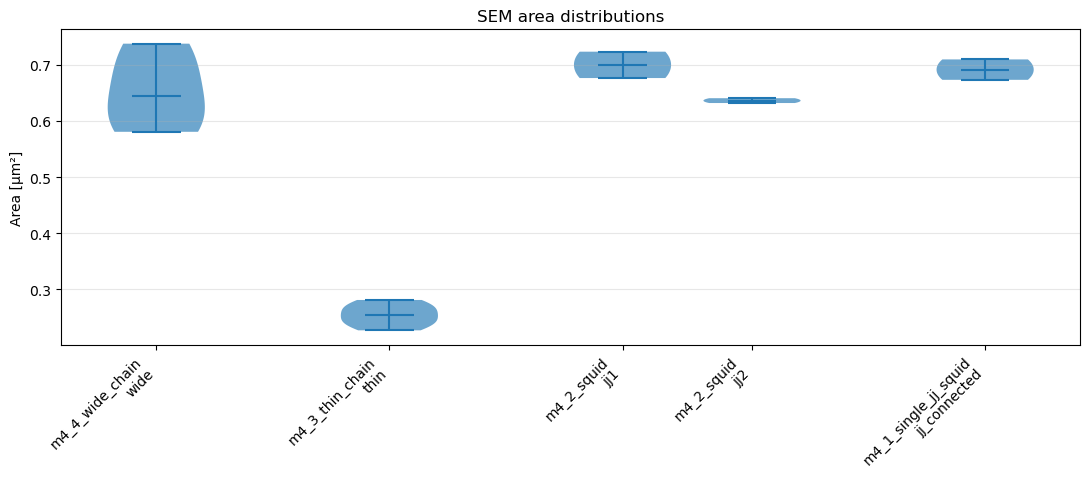

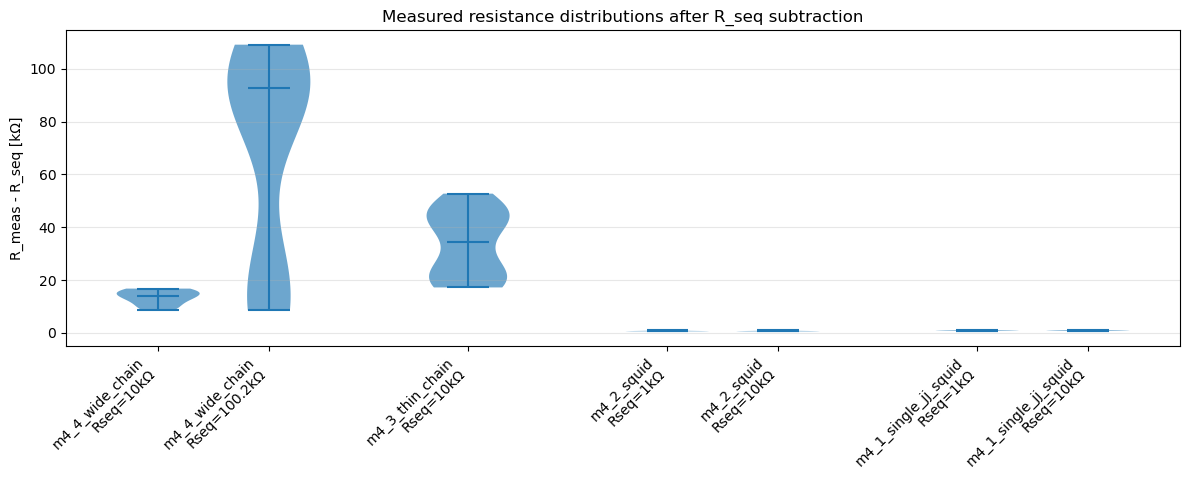

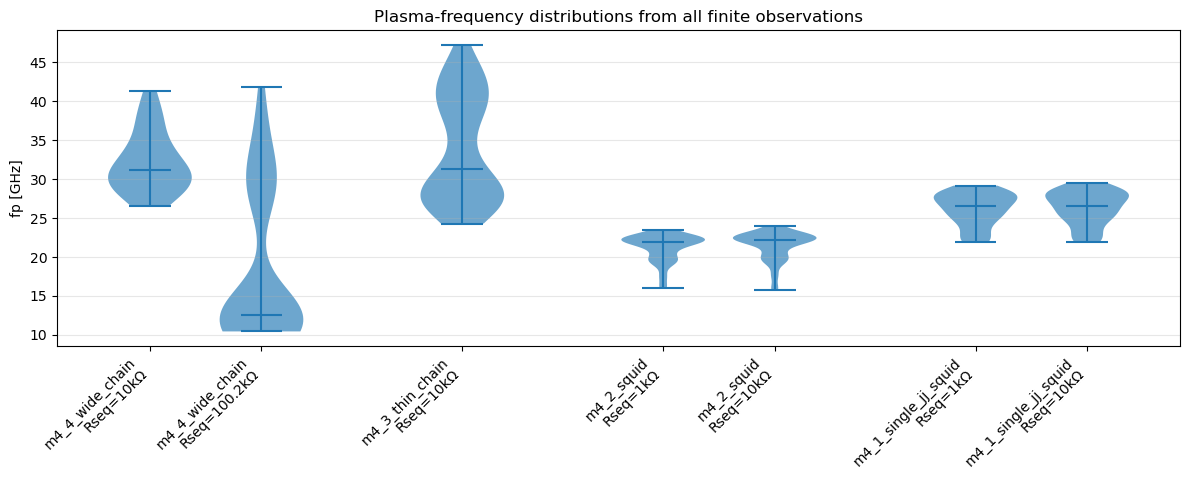

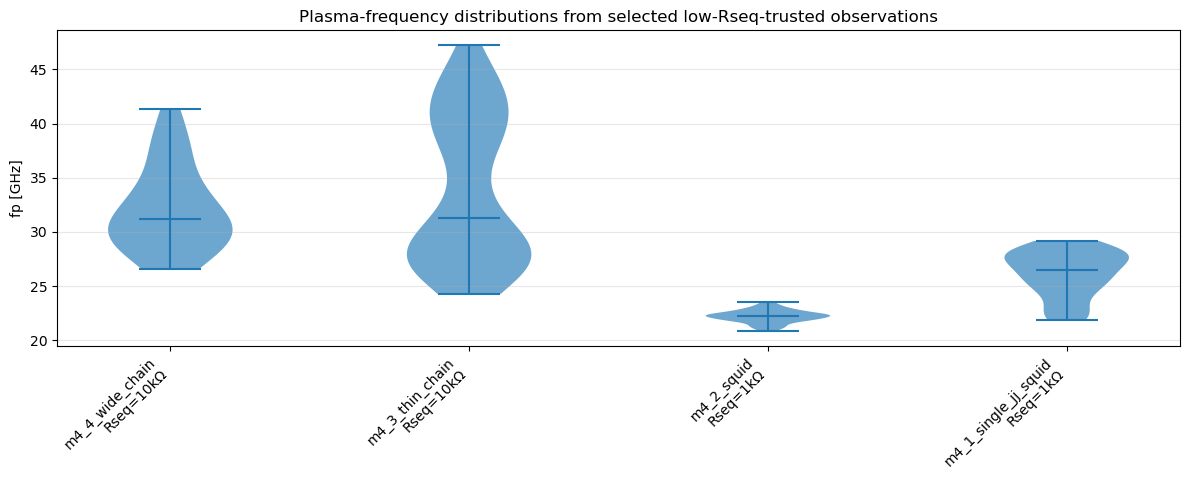

In [9]:
# ============================================================
# Violin-style distribution plots without seaborn
# ============================================================
def violin_by_groups(df, group_col, value_col, title, ylabel, subgroup_col=None, selected_col=None, figsize=(10, 4.8)):
    """
    If subgroup_col is None: one violin per group.
    If subgroup_col is given: one violin per (group, subgroup), spaced together.
    """
    if df.empty:
        print(f"No data for {title}")
        return

    data, labels, positions = [], [], []
    pos = 0
    groups = list(df[group_col].dropna().unique())
    for g in groups:
        gd = df[df[group_col] == g]
        if subgroup_col is None:
            vals = gd[value_col].dropna().to_numpy(float)
            if len(vals):
                data.append(vals); labels.append(str(g)); positions.append(pos); pos += 1
        else:
            subs = sorted(gd[subgroup_col].dropna().unique())
            for s in subs:
                vals = gd[gd[subgroup_col] == s][value_col].dropna().to_numpy(float)
                if len(vals):
                    data.append(vals); 
                    if subgroup_col == "R_seq_ohm":
                        lab = f"{g}\nRseq={float(s)/1e3:g}kΩ"
                    else:
                        lab = f"{g}\n{s}"
                    labels.append(lab); positions.append(pos); pos += 1
            pos += 0.8

    if not data:
        print(f"No finite data for {title}")
        return

    plt.figure(figsize=figsize)
    vp = plt.violinplot(data, positions=positions, showmeans=False, showmedians=True, widths=0.75)
    for body in vp['bodies']:
        body.set_alpha(0.65)
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Area distributions: all SEM area observations.
area_df = sem_area_dataframe(TEST_STRUCTURES)
violin_by_groups(area_df, "structure", "area_um2", "SEM area distributions", "Area [µm²]", subgroup_col="population", figsize=(11, 5))

# R_meas distributions: finite net resistance after R_seq subtraction, separated by structure and R_seq.
r_frames = []
for name, meta in metas.items():
    df = meta["resistance_df"].copy()
    df["structure"] = name
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"])]
    r_frames.append(finite)
r_all = pd.concat(r_frames, ignore_index=True) if r_frames else pd.DataFrame()
r_all["R_net_kOhm"] = r_all["R_net_ohm"] / 1e3
violin_by_groups(r_all, "structure", "R_net_kOhm", "Measured resistance distributions after R_seq subtraction", "R_meas - R_seq [kΩ]", subgroup_col="R_seq_ohm", figsize=(12, 5))

# Final wp/fp distributions: all observations × SEM samples, separated by structure and R_seq.
obs_fp_all = build_all_observation_fp(TEST_STRUCTURES, metas, selected_only=False)
violin_by_groups(obs_fp_all, "structure", "fp_GHz", "Plasma-frequency distributions from all finite observations", "fp [GHz]", subgroup_col="R_seq_ohm", figsize=(12, 5))

# Same but only selected/trusted observations.
obs_fp_sel = build_all_observation_fp(TEST_STRUCTURES, metas, selected_only=True)
violin_by_groups(obs_fp_sel, "structure", "fp_GHz", "Plasma-frequency distributions from selected low-Rseq-trusted observations", "fp [GHz]", subgroup_col="R_seq_ohm", figsize=(12, 5))

## 6. Old-style plots with both SEM-area and R-meas variance windows

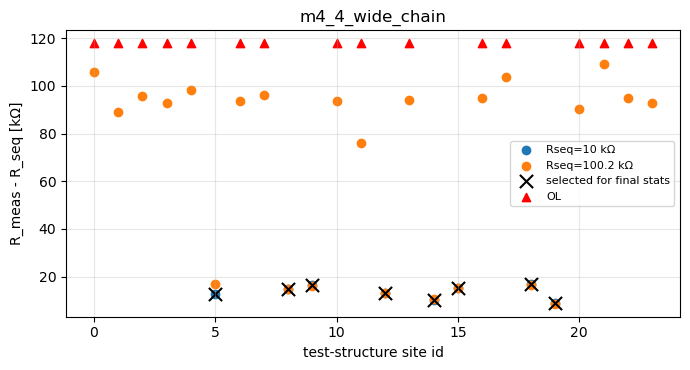

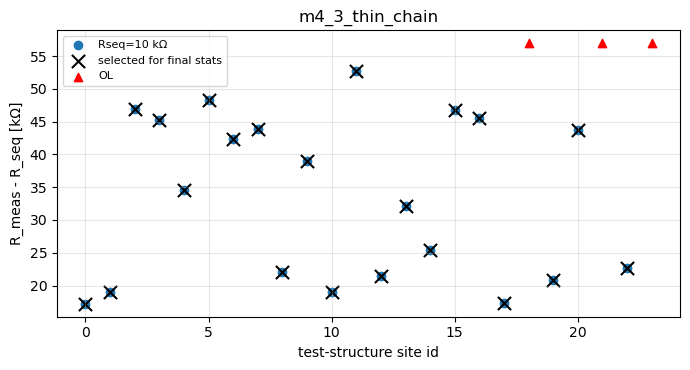

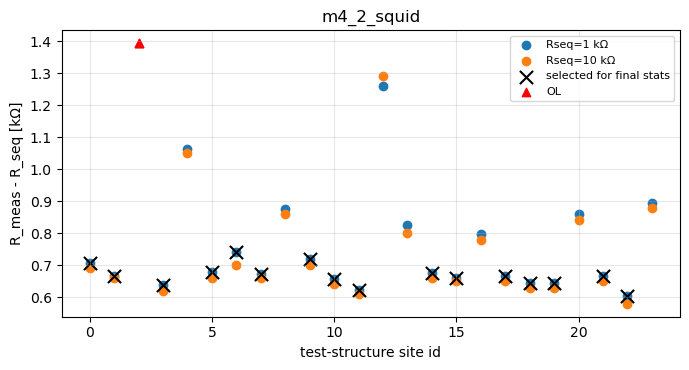

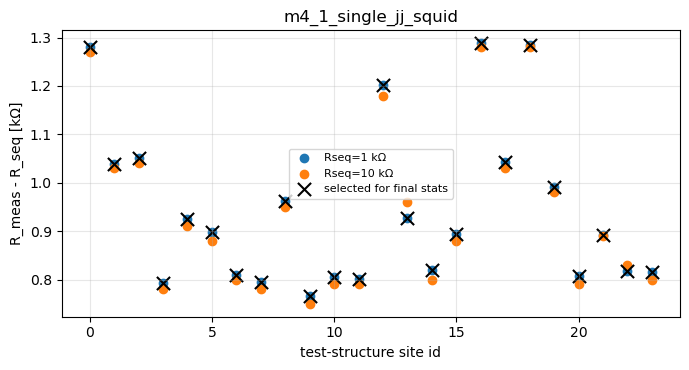

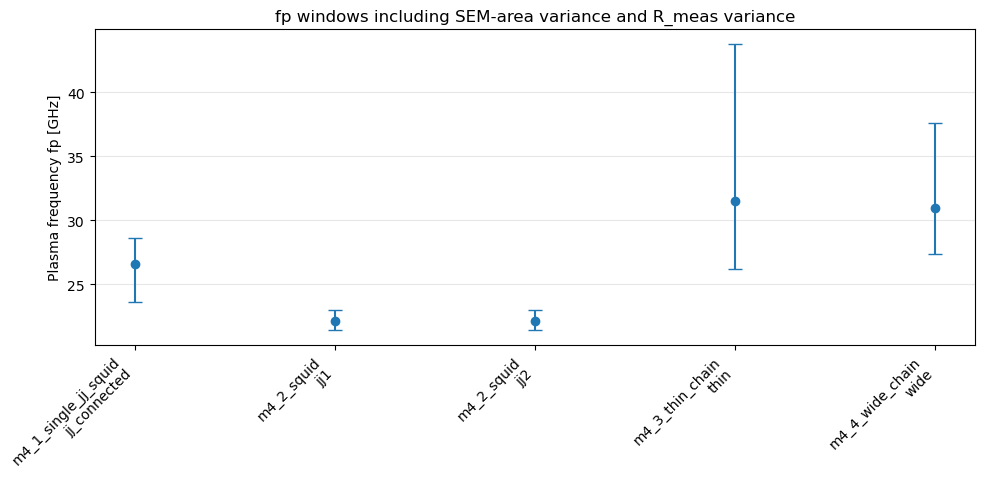

In [10]:
def plot_resistance_distribution(name: str, meta: Dict[str, Any]):
    df = meta["resistance_df"].copy()
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"])]
    selected = meta["selected_df"]

    plt.figure(figsize=(7, 3.8))
    for rseq, g in finite.groupby("R_seq_ohm"):
        plt.scatter(g["site_id"], g["R_net_ohm"] / 1e3, label=f"Rseq={rseq/1e3:g} kΩ")
    if len(selected):
        plt.scatter(selected["site_id"], selected["R_net_ohm"] / 1e3, s=90, marker="x", color="black", label="selected for final stats")
    ol = df[df["is_OL"]]
    if len(ol):
        ymax = (finite["R_net_ohm"].max() / 1e3 * 1.08) if len(finite) else 1.0
        plt.scatter(ol["site_id"], np.full(len(ol), ymax), marker="^", color="red", label="OL")
    plt.title(name)
    plt.xlabel("test-structure site id")
    plt.ylabel("R_meas - R_seq [kΩ]")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for name, meta in metas.items():
    plot_resistance_distribution(name, meta)


def plot_fp_windows_with_R_and_area(results: pd.DataFrame):
    """Error bars include both area window and selected R_meas window."""
    if results.empty:
        print("No results to plot.")
        return
    plt.figure(figsize=(10, 5))
    labels, y, yerr_low, yerr_high = [], [], [], []

    for (structure, junction), g in results.groupby(["structure", "junction"]):
        gm = g[(g["R_case"] == "R_median") & (g["area_case"] == "area_mean")]
        if gm.empty:
            continue
        f_mean = gm["fp_GHz"].iloc[0]
        # Use all combinations of R_low/R_median/R_high and area_low/mean/high for envelope.
        vals = g["fp_GHz"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
        if vals.size == 0:
            continue
        labels.append(f"{structure}\n{junction}")
        y.append(f_mean)
        yerr_low.append(abs(f_mean - np.nanmin(vals)))
        yerr_high.append(abs(np.nanmax(vals) - f_mean))

    x = np.arange(len(labels))
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=5)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Plasma frequency fp [GHz]")
    plt.title("fp windows including SEM-area variance and R_meas variance")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_fp_windows_with_R_and_area(results)

## 7. Notes on the lower-R_seq priority rule

The code does implement the anti-bias logic you requested. The high-`R_seq` tables are still displayed and plotted, but they are **not allowed to dominate the final extracted resistance** just because many dead structures have finite-but-large values. The final statistics are anchored by the lowest-`R_seq` table:

1. Find finite positive values at the lowest `R_seq`.
2. Use MAD filtering with `R_SELECTION["mad_z_thresh"]` to identify trusted site IDs.
3. For trusted sites, choose the lowest available `R_seq` measurement as the final selected observation.
4. Use those selected observations for the final resistance window and therefore for the final `fp` window.

If you want stricter dead-structure rejection, decrease `mad_z_thresh`; if you want to include broader variation, increase it.

## 8. Refactor note

At this point it is worth moving the following groups into a separate `.py` file later:

- resistance parsing and selection,
- SEM area statistics,
- JJ physics formulas,
- plotting helpers.

For now everything remains in one notebook so you can paste real tables quickly.